In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats.mstats import winsorize

In [3]:
xls = pd.ExcelFile('data/srcsc-2026-claims-cargo.xlsx')
xls.sheet_names

['freq', 'sev']

In [4]:
df_cargo_freq = pd.read_excel(xls, 'freq')
df_cargo_sev = pd.read_excel(xls, 'sev')

In [5]:
df_cargo_freq.head()

,policy_id,shipment_id,cargo_type,cargo_value,weight,route_risk,distance,transit_duration,pilot_experience,vessel_age,container_type,solar_radiation,debris_density,exposure,claim_count
0,CL-032806,S-981581,lithium,11070000.0,135000.0,4.0,NaN,6.619,18.017,19.380,QuantumCrate Module,0.288,0.127,0.340,0.0
1,CL-654613,S-366678,cobalt,8320000.0,160000.0,5.0,33.69,20.794,12.828,6.305,DockArc Freight Case,0.255,0.296,0.148,3.0
2,CL-569825,S-237760,lithium,12300000.0,150000.0,1.0,10.93,6.445,6.039,31.811,QuantumCrate Module,0.076,0.252,0.289,0.0
3,CL-707560,S-045399,supplies,500000.0,50000.0,4.0,13.49,9.583,17.533,9.695,DockArc Freight Case,0.150,0.350,0.813,0.0
4,CL-008111,S-280272,rare earths,2550000.0,30000.0,3.0,1.58,1.000,17.157,19.357,DeepSpace Haulbox,0.149,0.000,0.959,0.0


In [6]:
df_cargo_sev.head()

,claim_id,claim_seq,policy_id,shipment_id,cargo_type,cargo_value,weight,route_risk,distance,transit_duration,pilot_experience,vessel_age,container_type,solar_radiation,debris_density,exposure,claim_amount
0,CAR-C-0000001,1.0,CL-654613,S-366678,cobalt,8320000.0,160000.0,5.0,33.69,20.794,12.828,6.305,DockArc Freight Case,0.255,0.296,0.148,375109.0
1,CAR-C-0000002,2.0,CL-654613,S-366678,cobalt,8320000.0,160000.0,5.0,33.69,20.794,12.828,6.305,DockArc Freight Case,0.255,0.296,0.148,2476328.0
2,CAR-C-0000003,3.0,CL-654613,S-366678,cobalt,8320000.0,160000.0,NaN,33.69,20.794,12.828,6.305,DockArc Freight Case,0.255,0.296,0.148,247037.0
3,CAR-C-0000004,1.0,CL-389234,S-495879,supplies,900000.0,90000.0,3.0,18.80,10.635,28.573,19.665,LongHaul Vault Canister,0.255,0.155,0.180,76835.0
4,CAR-C-0000005,1.0,CL-315076,S-025302,gold,406800000.0,3000.0,4.0,52.57,31.143,17.106,14.623,DockArc Freight Case,0.222,0.408,0.115,36193774.0


In [8]:
common_cols = set(df_cargo_freq.columns).intersection(set(df_cargo_sev.columns))
print('Common columns:', common_cols)
uncommon_cols_freq = set(df_cargo_freq.columns) - common_cols
print('Uncommon columns in freq:', uncommon_cols_freq)
uncommon_cols_sev = set(df_cargo_sev.columns) - common_cols
print('Uncommon columns in sev:', uncommon_cols_sev)

Common columns: {'policy_id', 'shipment_id', 'cargo_value', 'transit_duration', 'cargo_type', 'solar_radiation', 'vessel_age', 'debris_density', 'distance', 'container_type', 'exposure', 'route_risk', 'pilot_experience', 'weight'}
Uncommon columns in freq: {'claim_count'}
Uncommon columns in sev: {'claim_id', 'claim_amount', 'claim_seq'}


In [9]:
def initial_cleaning(df):
    df = df.copy()
    print("Initial DataFrame shape:", df.shape)
    print(df.info())

    print(df["cargo_type"].unique(), df["container_type"].unique())
    df["cargo_type"] = df["cargo_type"].str.extract(r"^([A-Za-z\s]+)")
    df["container_type"] = df["container_type"].str.extract(r"^([A-Za-z\s]+)")
    print(df["cargo_type"].unique(), df["container_type"].unique())

    null_rows = df.isnull().any(axis=1).sum()
    null_pct = (null_rows / df.shape[0]) * 100
    print(f"Rows with nulls: {null_rows} ({null_pct:.2f}%)")
    print(f"<= 5%: {null_pct <= 5}")
    if null_pct <= 5:
        df.dropna(inplace=True)
        print("Dropped rows with null values.")

    # route_risk 1-5, distance 0-100, transit_duration 0-60, pilot_experience 0-30, vessel_age 0-50, solar_radiation 0-1, debris_density 0-1, exposure 0-1, claim_count 0-5
    df_filtered = df[
        (df["cargo_value"] >= 0)
        & (df["weight"] >= 0)
        & (df["route_risk"] >= 1)
        & (df["route_risk"] <= 5)
        & (df["distance"] >= 0)
        & (df["distance"] <= 100)
        & (df["transit_duration"] >= 0)
        & (df["transit_duration"] <= 60)
        & (df["pilot_experience"] >= 0)
        & (df["pilot_experience"] <= 30)
        & (df["vessel_age"] >= 0)
        & (df["vessel_age"] <= 50)
        & (df["solar_radiation"] >= 0)
        & (df["solar_radiation"] <= 1)
        & (df["debris_density"] >= 0)
        & (df["debris_density"] <= 1)
    ]
    print("Filtered shape:", df_filtered.shape)
    
    float_to_str_cols = ['route_risk']
    for col in float_to_str_cols:
        df_filtered[col] = df_filtered[col].astype(str)
    print("Converted specified float columns to string.", df_filtered.dtypes)
    
    return df_filtered

In [10]:
df_filtered_freq = initial_cleaning(df_cargo_freq)
df_filtered_freq = df_filtered_freq[
    (df_filtered_freq["claim_count"] >= 0)
    & (df_filtered_freq["claim_count"] <= 5)
]

Initial DataFrame shape: (124982, 15)
<class 'pandas.DataFrame'>
RangeIndex: 124982 entries, 0 to 124981
Data columns (total 15 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   policy_id         124681 non-null  str    
 1   shipment_id       124709 non-null  str    
 2   cargo_type        124690 non-null  str    
 3   cargo_value       124751 non-null  float64
 4   weight            124805 non-null  float64
 5   route_risk        124791 non-null  float64
 6   distance          124787 non-null  float64
 7   transit_duration  124826 non-null  float64
 8   pilot_experience  124762 non-null  float64
 9   vessel_age        124786 non-null  float64
 10  container_type    124696 non-null  str    
 11  solar_radiation   124789 non-null  float64
 12  debris_density    124794 non-null  float64
 13  exposure          124790 non-null  float64
 14  claim_count       124774 non-null  float64
dtypes: float64(11), str(4)
memory usage: 14.3

In [18]:
df_filtered_sev = initial_cleaning(df_cargo_sev)

Initial DataFrame shape: (30650, 17)
<class 'pandas.DataFrame'>
RangeIndex: 30650 entries, 0 to 30649
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   claim_id          30570 non-null  str    
 1   claim_seq         30610 non-null  float64
 2   policy_id         30564 non-null  str    
 3   shipment_id       30577 non-null  str    
 4   cargo_type        30573 non-null  str    
 5   cargo_value       30605 non-null  float64
 6   weight            30615 non-null  float64
 7   route_risk        30600 non-null  float64
 8   distance          30608 non-null  float64
 9   transit_duration  30591 non-null  float64
 10  pilot_experience  30596 non-null  float64
 11  vessel_age        30612 non-null  float64
 12  container_type    30587 non-null  str    
 13  solar_radiation   30603 non-null  float64
 14  debris_density    30595 non-null  float64
 15  exposure          30597 non-null  float64
 16  claim_amount  

In [19]:
df = df_filtered_freq.copy()

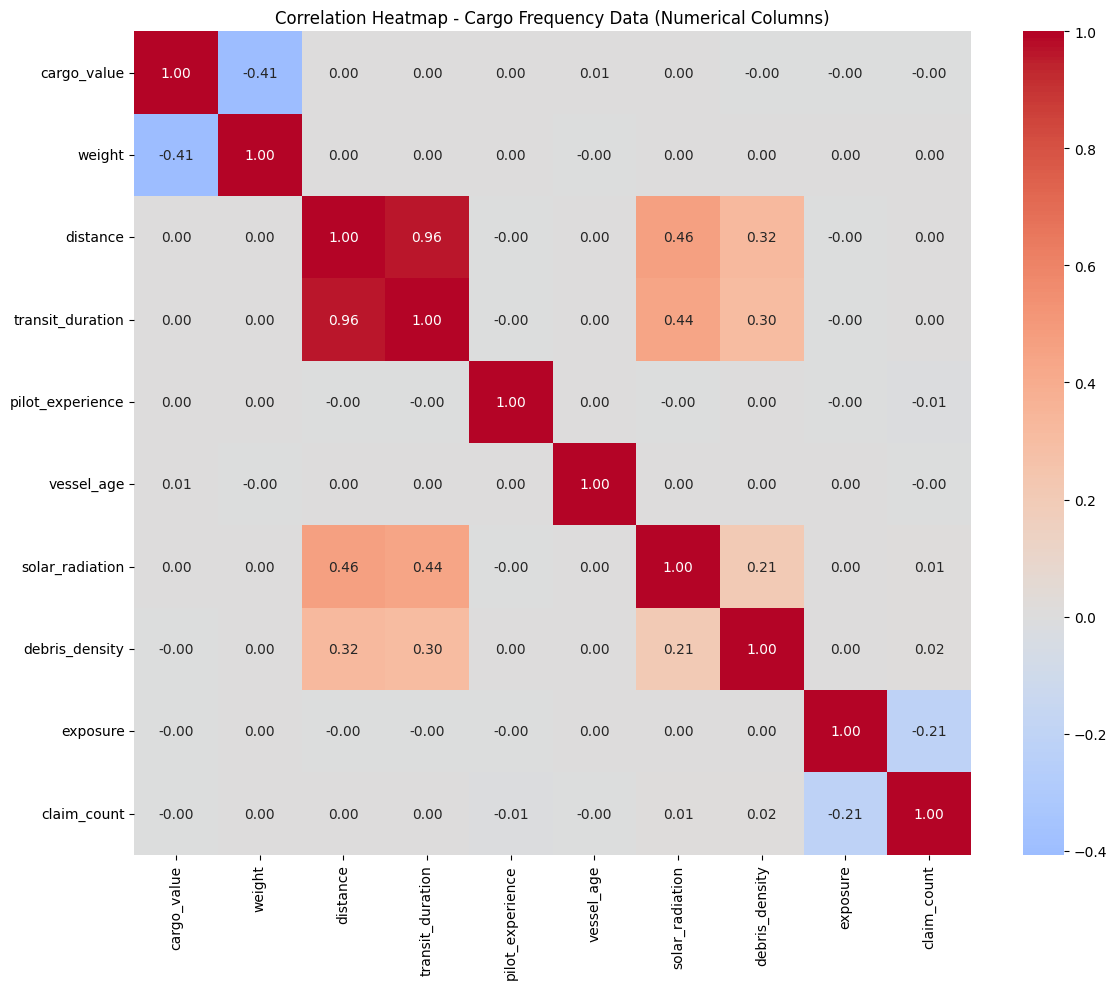

In [20]:
num_cols = df.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(12, 10))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap - Cargo Frequency Data (Numerical Columns)')
plt.tight_layout()
plt.show()

In [27]:
def eda_container_type(df, container_type):
    """
    Perform exploratory data analysis (EDA) for a specific container type.

    Parameters:
        df (pd.DataFrame): The input dataframe.
        container_type (str): The container type to filter and analyze.

    Returns:
        pd.DataFrame: The filtered dataframe for the specified container type.
    """
    # Filter dataframe
    df_filtered = df[df['container_type'] == container_type]
    print(f"EDA for container_type: {container_type}")
    print(f"Number of records: {len(df_filtered)}")
    # print("\nDescriptive statistics:")
    # print(df_filtered.describe(include='all'))
    
    # Plot numerical columns
    num_cols = df_filtered.select_dtypes(include=[np.number]).columns
    if len(num_cols) > 0:
        df_filtered[num_cols].hist(figsize=(15, 10), bins=30)
        plt.suptitle(f'Histograms for {container_type}', fontsize=16)
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()
        
    # Winsorize numerical columns to handle outliers, except 'claim_count'
    winsorized_cols = []
    for col in num_cols:
        if col in df_filtered.columns and col != 'claim_count':
            # Winsorize at 5% on each tail (remove top and bottom 1%)
            df_filtered[col] = winsorize(df_filtered[col], limits=[0.01, 0.01])
            winsorized_cols.append(col)
    
    if len(winsorized_cols) > 0:
        print(f"\nWinsorized columns (excluding 'claim_count'): {winsorized_cols}")
    
    # Plot histograms with winsorized data
    if len(num_cols) > 0:
        df_filtered[num_cols].hist(figsize=(15, 10), bins=30)
        plt.suptitle(f'Histograms for {container_type} (Winsorized)', fontsize=16)
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()
    return df_filtered

In [29]:
# df_filtered = eda_container_type(df, 'DeepSpace Haulbox')

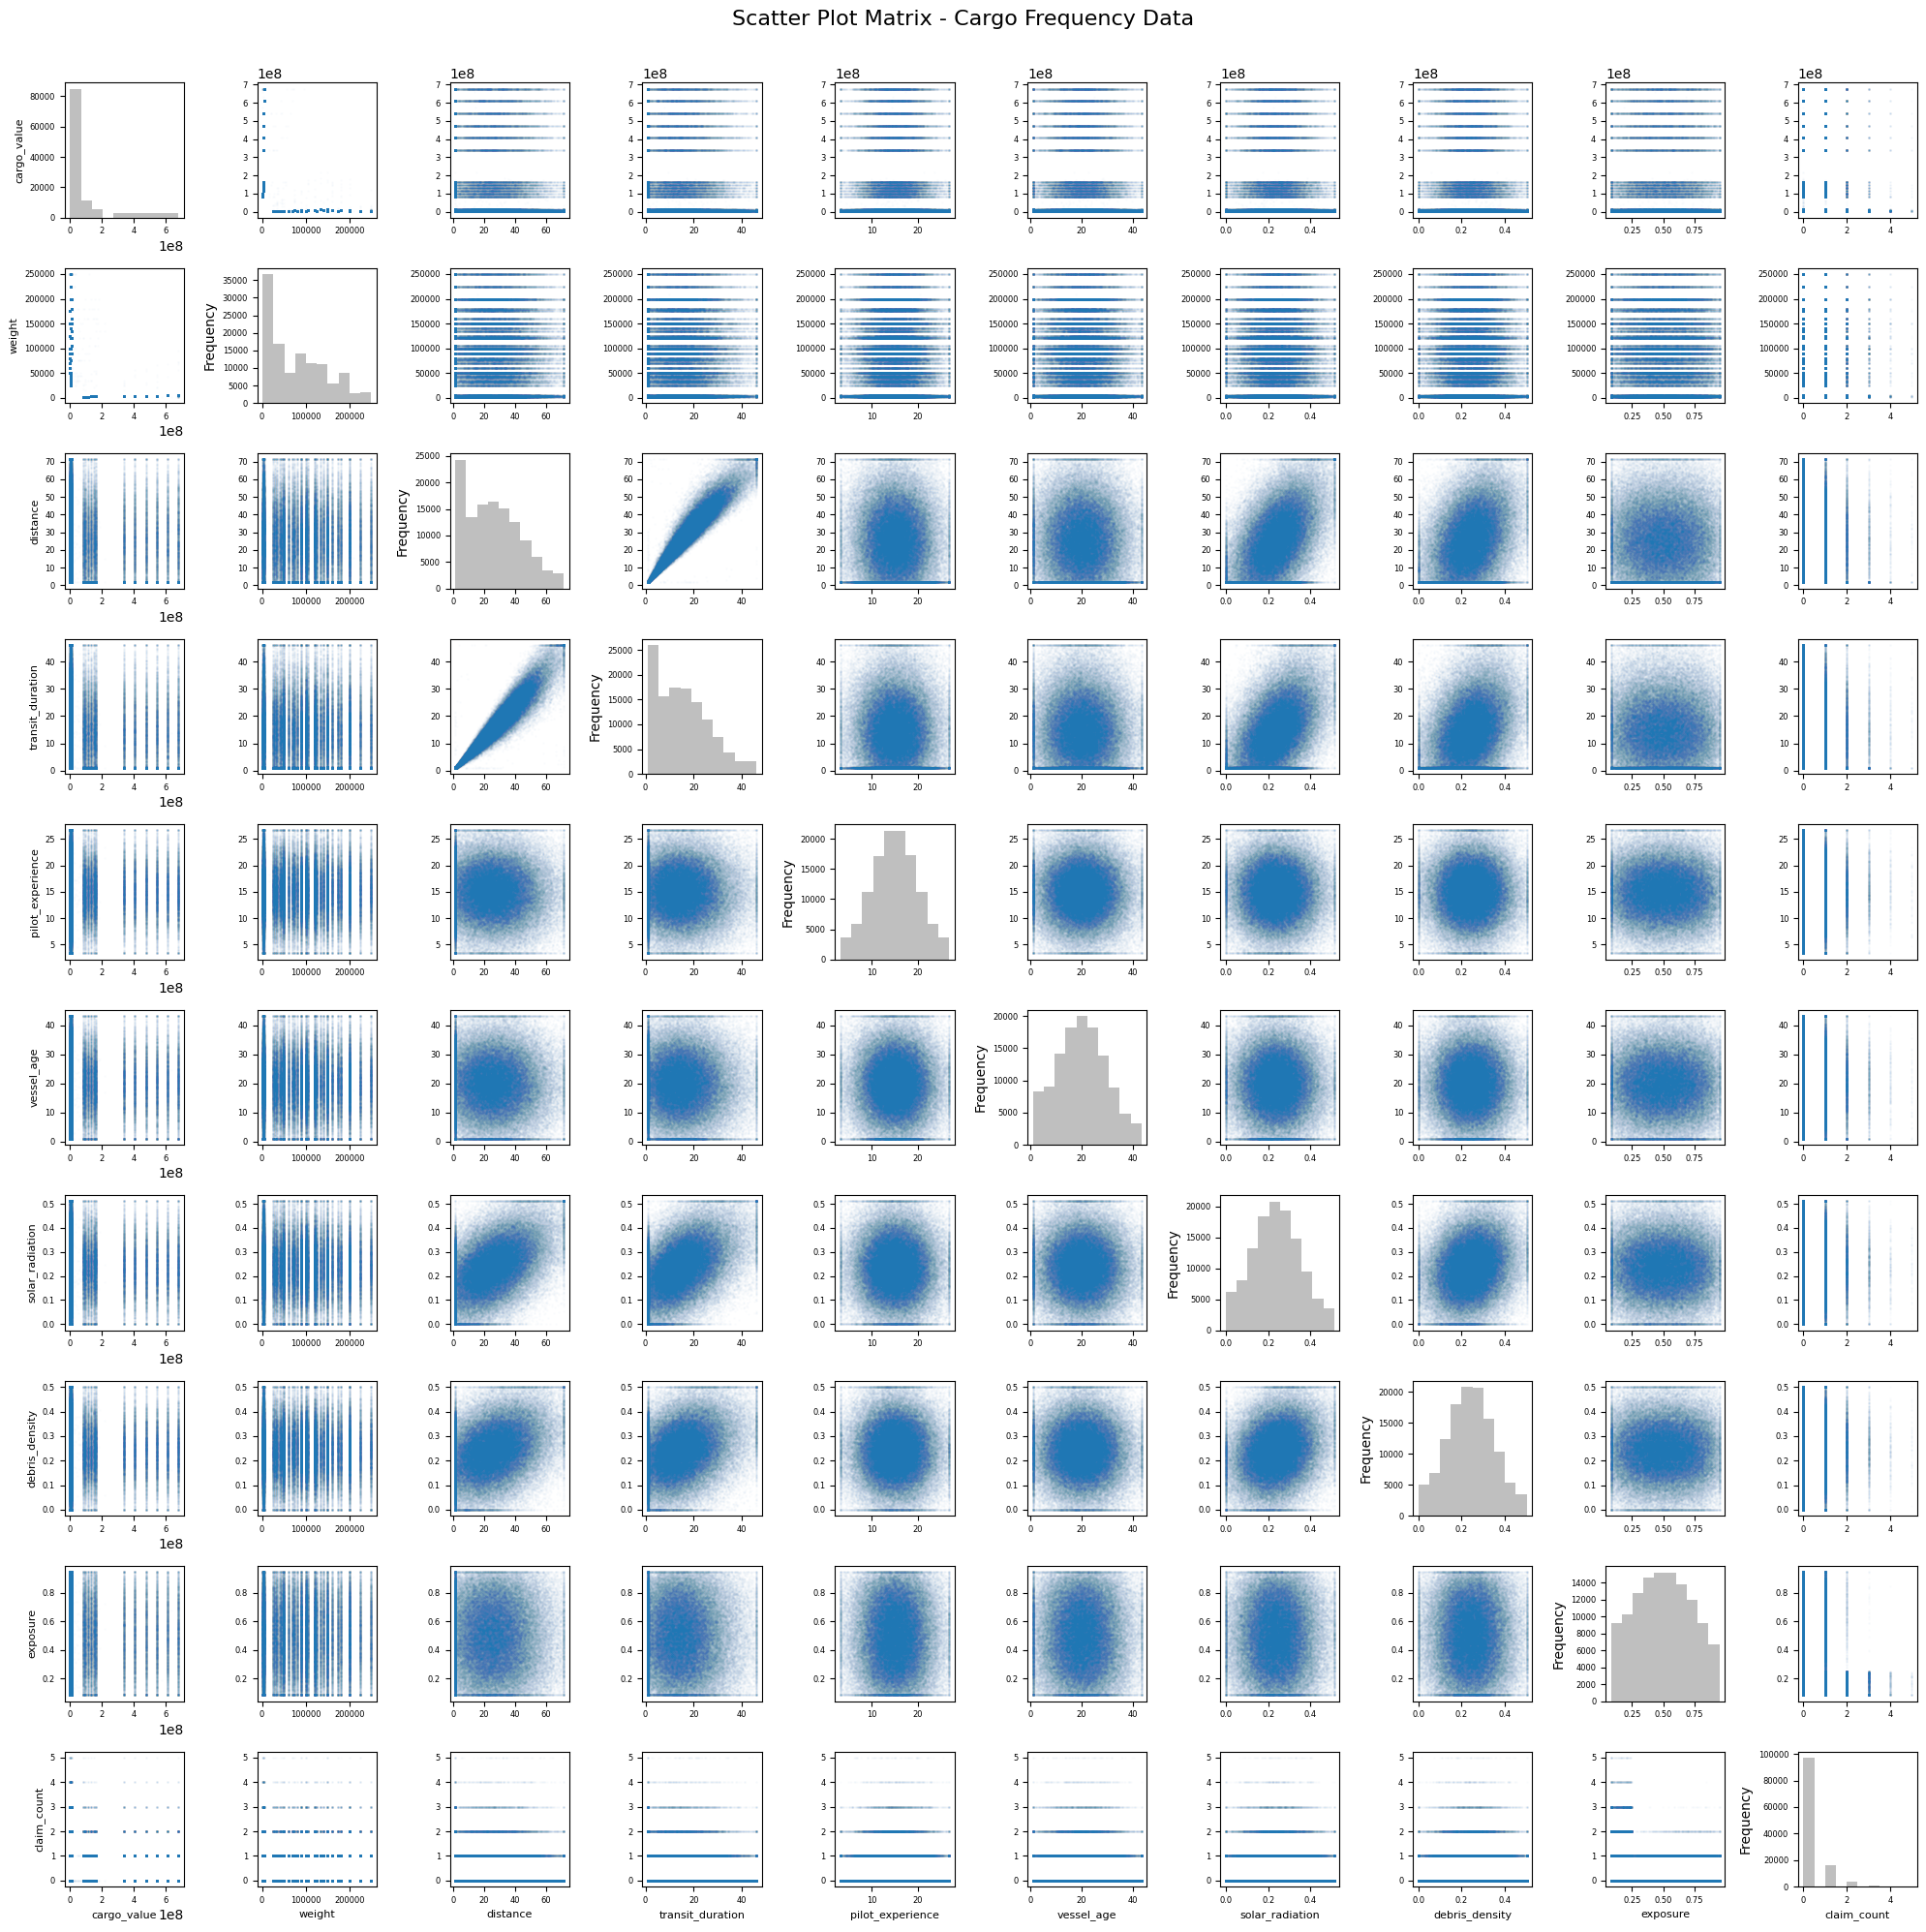

In [45]:
# Create scatter plots for each pair of numeric columns
n_cols = len(num_cols)
fig, axes = plt.subplots(n_cols, n_cols, figsize=(20, 20))

for i, col1 in enumerate(num_cols):
    for j, col2 in enumerate(num_cols):
        ax = axes[i, j]
        if i == j:
            # Diagonal: show histogram
            ax.hist(df[col1], alpha=0.5, color='gray')
            ax.set_ylabel('Frequency')
        else:
            # Off-diagonal: show scatter plot
            ax.scatter(df[col2], df[col1], alpha=0.01, s=1)
        
        # Labels
        if i == n_cols - 1:
            ax.set_xlabel(col2, fontsize=8)
        if j == 0:
            ax.set_ylabel(col1, fontsize=8)
        
        ax.tick_params(labelsize=6)

plt.suptitle('Scatter Plot Matrix - Cargo Frequency Data', fontsize=16, y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.show()